In [200]:
from dataclasses import dataclass
from typing import Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize as MPLNormalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 kept for side effects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import numpy as np
from numpy import pi

import torch
import geoopt

from funcshape.functions import Function
from torch.nn import Module
from botorch.models.transforms import Normalize
from botorch.utils.sampling import draw_sobol_samples
from botorch.posteriors.torch import TorchPosterior

import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import DirichletClassificationLikelihood
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel

from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.double)

In [201]:
@dataclass
class ProductBall:
    x: torch.Tensor  # (3,)
    radius: float = 1.0
    transform : Module = Normalize(d=3)
    
    def dist(self, c: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        device = c.device
        x_star = self.transform(self.x.reshape(-1, 3)).to(device)
        dist = []
        for i in range(len(t)):
            x_query = self.transform(torch.cat((c, t[i])).reshape(-1, 3))
            d = torch.sqrt(((x_star-x_query)**2).sum())
            dist.append(d)
        return torch.Tensor(dist, device=device)

    def label(self, c: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        d = self.dist(c, t)
        return (d <= self.radius).to(torch.double)

In [202]:
def make_grid_point_cloud(nx=10, ny=10, nz=10):
    xs = torch.linspace(-3.0, 3.0, steps=nx, device=device)
    ys = torch.linspace(-3.0, 3.0, steps=ny, device=device)
    t = torch.linspace(0.0, 1.0, steps=nz, device=device)
    ft = torch.linspace(20.0, 100.0, steps=nz, device=device)

    grid = torch.meshgrid(xs, ys, indexing="ij")
    points = torch.stack(grid, dim=-1).reshape(-1, 2)
    grid_3d = torch.meshgrid(xs, ys, ft, indexing="ij")
    points_3d = torch.stack(grid_3d, dim=-1).reshape(-1, 3)
    return points, Function(t, ft.reshape(nz, 1)), points_3d

In [203]:
bounds = torch.tensor(
    [
        [-3.0, 3.0], 
        [-3.0, 3.0],
        [20.0, 100.0]
    ]
    ).T
bounds_xy = torch.tensor([[-3.0, 3.0], [-3.0, 3.0]]).T
ball = ProductBall(
    torch.Tensor([0.0, 0.0, 45.0]), 
    radius=0.5,
    transform = Normalize(d=3, bounds = bounds)
    )
grid_xy, f, grid_xyz = make_grid_point_cloud()

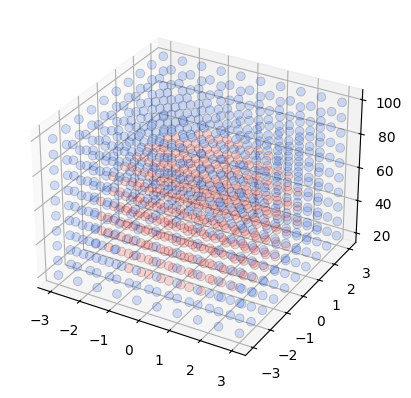

In [204]:
ground_truth_labels = torch.ones(grid_xyz.shape[0])
for i in range(grid_xy.shape[0]):
    ground_truth_labels[10*i:10*i+10] = ball.label(grid_xy[i,:], f.fx)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")
colors = np.where(ground_truth_labels > 0.5, "#ef4444", "#2563eb")
ax.scatter(
    grid_xyz[:, 0], grid_xyz[:, 1], grid_xyz[:, 2],
    c=colors,
    s=40,
    depthshade=False,
    edgecolors="k",
    linewidths=0.6,
    alpha=0.2,
    zorder=4,
)
plt.show()

In [205]:
def generate_random_samples(bounds_xy, T_min, T_max, n_temps):
    random_xy = draw_sobol_samples(bounds=bounds_xy, n=1, q=10).squeeze(0)
    ft = torch.linspace(T_min, T_max, steps=n_temps).reshape(-1, 1)
    train_X, train_Y = [],[]
    for xy in random_xy:
        train_Y.append(ball.label(xy, ft))
        xy = xy.view(-1, 1, 2).expand(-1, len(ft), -1).squeeze(0)
        train_X.append(torch.cat([xy, ft], dim=1))

    train_X = torch.stack(train_X).reshape(-1,3)
    train_Y = torch.stack(train_Y).reshape(-1, 1)

    return train_X, train_Y

T_MIN = 20.0
T_MAX = 100.0
N_TEMPS = 5
train_X, train_Y = generate_random_samples(bounds_xy, T_MIN, T_MAX, N_TEMPS)
scatter_kwargs = {
    "s": 40,
    "edgecolors": "k",
    "linewidths": 0.6,
    "alpha": 0.5,
    "zorder": 4,
}

In [206]:
class DirichletGPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_classes, transform : Module = Normalize(d=3)):
        super(DirichletGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean(batch_shape=torch.Size((num_classes,)))
        self.covar_module = ScaleKernel(
            RBFKernel(batch_shape=torch.Size((num_classes,))),
            batch_shape=torch.Size((num_classes,)),
        )
        self.transform = transform

    def forward(self, x):
        x = self.transform(x)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [207]:
def fit_dirchlet_gp(train_x, model, likelihood, n_iterations=200):
    model.train()
    likelihood.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    pbar = tqdm(range(n_iterations), desc="Fitting GP Model")
    for _ in pbar:
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, likelihood.transformed_targets).sum()
        loss.backward()

        pbar.set_postfix(
            loss=loss.item(), 
            lengthscale = model.covar_module.base_kernel.lengthscale.mean().item(),
            noise = model.likelihood.second_noise_covar.noise.mean().item()
        )
        optimizer.step()
    
    return model, likelihood

In [208]:
likelihood = DirichletClassificationLikelihood(
    train_Y.long().squeeze(), 
    learn_additional_noise=True
)
model = DirichletGPModel(
    train_X, 
    likelihood.transformed_targets, 
    likelihood, 
    num_classes = likelihood.num_classes,
    transform = Normalize(d=3, bounds = bounds)
    )

model, likelihood = fit_dirchlet_gp(train_X, model, likelihood, n_iterations=200)

Fitting GP Model: 100%|██████████| 200/200 [00:00<00:00, 476.55it/s, lengthscale=0.328, loss=4.78, noise=1.25]


In [209]:
def PosteriorModel(X, model):
    model.eval()
    dist = model(X)
    return TorchPosterior(dist)

/Users/knv2/Documents/codebase/envs/MaternGaBO/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


(<Figure size 640x480 with 3 Axes>,
 [<Axes3D: title={'center': 'Accuracy 0.91'}>, <Axes3D: >])

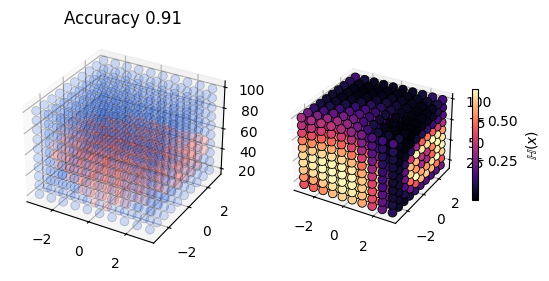

In [210]:
def plot_model_posterior(model, grid_xyz, ax = None):
    posterior = PosteriorModel(grid_xyz, model)
    pred_samples = posterior.sample(torch.Size((256,))).exp()
    probabilities = (pred_samples / pred_samples.sum(-2, keepdim=True)).mean(0)
    entropy = torch.special.entr(probabilities).sum(dim=0)
    labels = posterior.loc.max(0)[1]
    accuracy = (labels==ground_truth_labels).sum()/len(ground_truth_labels)

    if ax is None:
        fig = plt.figure()
        ax1 = fig.add_subplot(1, 2, 1, projection="3d")
        ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    else:
        ax1 = ax[0]
        ax2 = ax[1]
        fig = plt.gcf()
    colors = np.where(labels > 0.5, "#ef4444", "#2563eb")
    ax1.scatter(
        grid_xyz[:, 0], grid_xyz[:, 1], grid_xyz[:, 2],
        c=colors,
        s=40,
        depthshade=False,
        edgecolors="k",
        linewidths=0.6,
        alpha=0.2,
        zorder=4,
    )
    ax1.set_title(f"Accuracy {accuracy:.2f}")

    img = ax2.scatter(
        grid_xyz[:, 0], grid_xyz[:, 1], grid_xyz[:, 2],
        c=entropy,
        s=40,
        depthshade=False,
        edgecolors="k",
        linewidths=0.6,
        cmap="magma"
    )

    cb = ax2.figure.colorbar(img, use_gridspec=True, shrink=0.3)
    cb.set_label(r"$\mathbb{H}(x)$")

    return fig, [ax1, ax2]

plot_model_posterior(model, grid_xyz)

In [211]:
class SRSFHilbertSphere(geoopt.Manifold):
    """
    Hilbert Sphere manifold for functional data using SRSF representation.
    
    The Square Root Slope Function (SRSF) transformation maps functions to a
    Hilbert sphere, enabling efficient elastic shape analysis of functional data.
    
    For a function f: [0,1] -> R^d, the SRSF is defined as:
        q(t) = sign(f'(t)) * sqrt(|f'(t)|)
    
    The manifold structure is that of the unit sphere in L^2([0,1], R^d).
    
    Parameters
    ----------
    sampling_points : int
        Number of discrete sampling points for the functions
    ambient_dim : int, optional
        Dimension of the codomain (default: 1 for scalar functions)
    
    Attributes
    ----------
    name : str
        Name of the manifold
    reversible : bool
        Whether the exponential map is reversible
    ndim : int
        Number of dimensions
    """
    
    name = "SRSF Hilbert Sphere"
    reversible = False
    ndim = 1
    
    def __init__(self, sampling_points: int, ambient_dim: int = 1):
        super().__init__()
        self.sampling_points = sampling_points
        self.ambient_dim = ambient_dim
        self.dt = 1.0 / (sampling_points - 1)  # Time step for [0,1] discretization
        
    def _check_point_on_manifold(
        self, x: torch.Tensor, *, atol: float = 1e-5, rtol: float = 1e-5
    ) -> Tuple[bool, Optional[str]]:
        """Check if point lies on the Hilbert sphere (has unit L2 norm)."""
        try:
            self._check_shape(x, "x")
        except ValueError as e:
            return False, str(e)
        
        # Compute L2 norm using trapezoidal rule
        norm_sq = self._l2_inner(x, x)
        norm = torch.sqrt(norm_sq)
        
        ok = torch.allclose(norm, torch.ones_like(norm), atol=atol, rtol=rtol)
        if not ok:
            reason = f"L2 norm is {norm.mean().item():.6f}, expected 1.0"
            return False, reason
        return True, None
    
    def _check_vector_on_tangent(
        self, 
        x: torch.Tensor, 
        u: torch.Tensor, 
        *, 
        atol: float = 1e-5, 
        rtol: float = 1e-5
    ) -> Tuple[bool, Optional[str]]:
        """Check if vector u is tangent to the sphere at point x."""
        self._check_shape(x, "x")
        self._check_shape(u, "u")
        
        # Tangent vectors must be orthogonal to the point: <x, u> = 0
        inner_prod = self._l2_inner(x, u)
        
        ok = torch.allclose(
            inner_prod, torch.zeros_like(inner_prod), atol=atol, rtol=rtol
        )
        if not ok:
            reason = f"Inner product <x,u> = {inner_prod.mean().item():.6f}, expected 0.0"
            return False, reason
        return True, None
    
    def _l2_inner(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Compute L2 inner product using trapezoidal rule integration.
        
        Returns scalar for each batch element.
        """
        # Pointwise product
        pointwise = (x * y).sum(dim=-1)  # Sum over ambient dimensions
        
        # Trapezoidal rule: integral ≈ dt * (0.5*f[0] + f[1] + ... + f[n-2] + 0.5*f[n-1])
        integral = torch.zeros(pointwise.shape[:-1], device=x.device, dtype=x.dtype)
        integral = integral + 0.5 * pointwise[..., 0]
        integral = integral + pointwise[..., 1:-1].sum(dim=-1)
        integral = integral + 0.5 * pointwise[..., -1]
        integral = integral * self.dt
        
        return integral
    
    def projx(self, x: torch.Tensor) -> torch.Tensor:
        """
        Project point onto the manifold (normalize to unit L2 norm).
        
        Parameters
        ----------
        x : torch.Tensor
            Point to project, shape (..., sampling_points, ambient_dim)
            
        Returns
        -------
        torch.Tensor
            Projected point on the Hilbert sphere
        """
        norm_sq = self._l2_inner(x, x)
        norm = torch.sqrt(norm_sq)
        
        # Add dimensions for broadcasting
        while norm.ndim < x.ndim:
            norm = norm.unsqueeze(-1)
        
        return x / (norm + 1e-8)
    
    def proju(self, x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        """
        Project vector u onto the tangent space at point x.
        
        The tangent space at x consists of all vectors orthogonal to x.
        Projection: u_tangent = u - <u,x> * x
        
        Parameters
        ----------
        x : torch.Tensor
            Point on manifold, shape (..., sampling_points, ambient_dim)
        u : torch.Tensor
            Vector to project, shape (..., sampling_points, ambient_dim)
            
        Returns
        -------
        torch.Tensor
            Projected tangent vector
        """
        inner = self._l2_inner(u, x)
        
        # Add dimensions for broadcasting
        while inner.ndim < x.ndim:
            inner = inner.unsqueeze(-1)
        
        return u - inner * x
    
    def inner(
        self, 
        x: torch.Tensor, 
        u: torch.Tensor, 
        v: Optional[torch.Tensor] = None, 
        *, 
        keepdim: bool = False
    ) -> torch.Tensor:
        """
        Compute inner product in the tangent space at x.
        
        On the Hilbert sphere, the Riemannian metric is inherited from
        the ambient L2 space.
        
        Parameters
        ----------
        x : torch.Tensor
            Point on manifold
        u : torch.Tensor
            First tangent vector
        v : torch.Tensor, optional
            Second tangent vector (if None, compute norm of u)
        keepdim : bool
            Keep reduced dimensions
            
        Returns
        -------
        torch.Tensor
            Inner product value
        """
        if v is None:
            v = u
        
        result = self._l2_inner(u, v)
        
        if keepdim:
            while result.ndim < x.ndim:
                result = result.unsqueeze(-1)
        
        return result
    
    def expmap(
        self, x: torch.Tensor, u: torch.Tensor, *, norm_u: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Exponential map: move along geodesic from x in direction u.
        
        On the sphere, geodesics are great circles:
            exp_x(u) = cos(||u||) * x + sin(||u||) / ||u|| * u
        
        Parameters
        ----------
        x : torch.Tensor
            Base point on manifold
        u : torch.Tensor
            Tangent vector at x
        norm_u : torch.Tensor, optional
            Pre-computed norm of u
            
        Returns
        -------
        torch.Tensor
            Point on manifold reached by exponential map
        """
        if norm_u is None:
            norm_u = torch.sqrt(self._l2_inner(u, u))
        
        # Add dimensions for broadcasting
        norm_u_expanded = norm_u
        while norm_u_expanded.ndim < x.ndim:
            norm_u_expanded = norm_u_expanded.unsqueeze(-1)
        
        # Handle zero tangent vector
        mask = (norm_u > 1e-8).float()
        while mask.ndim < x.ndim:
            mask = mask.unsqueeze(-1)
        
        cos_norm = torch.cos(norm_u_expanded)
        sin_norm = torch.sin(norm_u_expanded)
        
        # When norm is small, sin(norm)/norm ≈ 1
        sinc = torch.where(
            norm_u_expanded > 1e-8,
            sin_norm / norm_u_expanded,
            torch.ones_like(norm_u_expanded)
        )
        
        return cos_norm * x + sinc * u
    
    def retr(self, x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        """
        Retraction: fast approximate exponential map.
        
        Uses projection-based retraction: retr_x(u) = proj(x + u)
        
        Parameters
        ----------
        x : torch.Tensor
            Base point on manifold
        u : torch.Tensor
            Tangent vector at x
            
        Returns
        -------
        torch.Tensor
            Point on manifold
        """
        return self.projx(x + u)
    
    def logmap(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Logarithmic map: compute tangent vector pointing from x to y.
        
        On the sphere:
            log_x(y) = (y - <x,y> * x) * arccos(<x,y>) / ||y - <x,y> * x||
        
        Parameters
        ----------
        x : torch.Tensor
            Base point on manifold
        y : torch.Tensor
            Target point on manifold
            
        Returns
        -------
        torch.Tensor
            Tangent vector at x pointing toward y
        """
        inner_xy = self._l2_inner(x, y)
        
        # Add dimensions for broadcasting
        inner_xy_expanded = inner_xy
        while inner_xy_expanded.ndim < x.ndim:
            inner_xy_expanded = inner_xy_expanded.unsqueeze(-1)
        
        # Project y onto tangent space at x
        u = y - inner_xy_expanded * x
        
        # Compute norm of projection
        norm_u = torch.sqrt(self._l2_inner(u, u))
        norm_u_expanded = norm_u
        while norm_u_expanded.ndim < x.ndim:
            norm_u_expanded = norm_u_expanded.unsqueeze(-1)
        
        # Compute angle
        angle = torch.acos(torch.clamp(inner_xy, -1.0 + 1e-7, 1.0 - 1e-7))
        angle_expanded = angle
        while angle_expanded.ndim < x.ndim:
            angle_expanded = angle_expanded.unsqueeze(-1)
        
        # Scale by angle/norm
        scale = torch.where(
            norm_u_expanded > 1e-8,
            angle_expanded / norm_u_expanded,
            torch.ones_like(norm_u_expanded)
        )
        
        return u * scale
    
    def transp(
        self, x: torch.Tensor, y: torch.Tensor, v: torch.Tensor
    ) -> torch.Tensor:
        """
        Parallel transport of vector v from tangent space at x to tangent space at y.
        
        Uses the projection-based parallel transport.
        
        Parameters
        ----------
        x : torch.Tensor
            Starting point
        y : torch.Tensor
            Ending point
        v : torch.Tensor
            Tangent vector at x
            
        Returns
        -------
        torch.Tensor
            Transported tangent vector at y
        """
        return self.proju(y, v)
    
    def egrad2rgrad(self, x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        """
        Convert Euclidean gradient to Riemannian gradient.
        
        The Riemannian gradient is the projection of the Euclidean gradient
        onto the tangent space at x.
        
        Parameters
        ----------
        x : torch.Tensor
            Point on manifold
        u : torch.Tensor
            Euclidean gradient at x
            
        Returns
        -------
        torch.Tensor
            Riemannian gradient (tangent vector at x)
        """
        return self.proju(x, u)
    
    def _random(
        self, *size, n_basis: Optional[int]= 10, dtype: Optional[torch.dtype] = None, device: Optional[torch.device] = None
    ) -> torch.Tensor:
        """
        Generate random point on the manifold.
        
        Parameters
        ----------
        size : tuple
            Desired shape (excluding the manifold dimensions)
        dtype : torch.dtype, optional
            Data type
        device : torch.device, optional
            Device
            
        Returns
        -------
        torch.Tensor
            Random point on the Hilbert sphere
        """
        if dtype is None:
            dtype = torch.get_default_dtype()
        
        # Generate random function and project to sphere
        out = []
        x0 = self.origin(*size)
        for i in range(size[0]):
            x = torch.linspace(0, 1, steps=self.sampling_points, dtype=dtype, device=device)
            wl = 20*torch.randn(n_basis, 1)
            with torch.no_grad():
                norm = wl.norm(p=1)
                if norm > 1.0 - 1e-6:
                    wl *= (1 - 1e-6) / norm
            nvec = torch.arange(1, n_basis + 1)
            basis = torch.sin(pi * nvec * x.reshape(1, -1, 1)) / (pi * nvec)
            fx = x0[i,...] + basis @ wl
            out.append(fx)
        out = torch.stack(out).reshape(size+(self.sampling_points, self.ambient_dim))
        return self.projx(out)
    
    def origin(
        self, 
        *size, 
        dtype: Optional[torch.dtype] = None, 
        device: Optional[torch.device] = None
    ) -> torch.Tensor:
        """
        Generate the origin point (constant function with appropriate norm).
        
        Parameters
        ----------
        size : tuple
            Desired shape (excluding the manifold dimensions)
        dtype : torch.dtype, optional
            Data type
        device : torch.device, optional
            Device
            
        Returns
        -------
        torch.Tensor
            Origin point on the manifold
        """
        if dtype is None:
            dtype = torch.get_default_dtype()
        
        shape = size + (self.sampling_points, self.ambient_dim)
        x = torch.ones(shape, dtype=dtype, device=device)
        return self.projx(x)
    
    def function_to_srsf(self, f: torch.Tensor) -> torch.Tensor:
        """
        Convert function to its SRSF representation.
        
        SRSF(f)(t) = f'(t) / sqrt(|f'(t)|)
        
        Parameters
        ----------
        f : torch.Tensor
            Function values, shape (..., sampling_points, ambient_dim)
            
        Returns
        -------
        torch.Tensor
            SRSF representation (on the Hilbert sphere)
        """
        # Compute derivative using central differences
        df = torch.zeros_like(f)
        df[..., 1:-1, :] = (f[..., 2:, :] - f[..., :-2, :]) / (2 * self.dt)
        df[..., 0, :] = (f[..., 1, :] - f[..., 0, :]) / self.dt
        df[..., -1, :] = (f[..., -1, :] - f[..., -2, :]) / self.dt
        
        # Compute SRSF
        df_norm = torch.sqrt((df ** 2).sum(dim=-1, keepdim=True))
        srsf = df / torch.sqrt(df_norm + 1e-8)
        
        # Project onto sphere
        return self.projx(srsf)
    
    def srsf_to_function(
        self, q: torch.Tensor, f0: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Convert SRSF representation back to function (approximate).
        
        Integrates: f(t) = f(0) + integral(q(s) * |q(s)|, s=0..t)
        
        Parameters
        ----------
        q : torch.Tensor
            SRSF representation
        f0 : torch.Tensor, optional
            Initial value f(0), shape (..., ambient_dim)
            
        Returns
        -------
        torch.Tensor
            Reconstructed function
        """
        if f0 is None:
            f0 = torch.zeros(
                q.shape[:-2] + (self.ambient_dim,), 
                dtype=q.dtype, 
                device=q.device
            )
        
        # Compute |q|
        q_norm = torch.sqrt((q ** 2).sum(dim=-1, keepdim=True))
        
        # Integrand: q * |q|
        integrand = q * q_norm
        
        # Cumulative trapezoidal integration
        f = torch.zeros_like(q)
        f[..., 0, :] = f0
        
        for i in range(1, self.sampling_points):
            f[..., i, :] = f[..., i-1, :] + 0.5 * self.dt * (
                integrand[..., i, :] + integrand[..., i-1, :]
            )

        # Normalize the co-domain
        f = f / f[..., -1:, :]    # enforce φ(1)=1
        f[..., 0, :] = 0.0

        return f
    
    def random(
        self,
        n_samples: int,
        n_basis: int = 10,
        sigma: float = 0.35,
        beta: float = 2.0,
        device=None,
        dtype=None,
    ):
        """
        Sample random monotone warpings φ(t) using Riemannian normal sampling
        on the SRD (Hilbert sphere) at the identity warp.

        Steps:
        1. Construct cosine basis e_k in T_p S^∞ (orthogonal to constant function).
        2. Sample Gaussian coefficients with spectrum λ_k ~ k^{-2β}.
        3. Form tangent vector v and map to sphere via expmap.
        4. Recover φ(t) = ∫ ψ(s)^2 ds normalized to φ(1)=1.

        Returns
        -------
        t : (T,)
        phi : (N, T, 1)
        psi : (N, T, 1)
        """
        if device is None:
            device = torch.device("cpu")
        if dtype is None:
            dtype = torch.get_default_dtype()

        T = self.sampling_points

        # Base point (identity warp SRD psi ≡ 1)
        p = self.origin(n_samples, dtype=dtype, device=device)  # (N,T,1)

        # Build cosine basis: e_k(t) = sqrt(2) cos(k pi t)
        t = torch.linspace(0., 1., T, device=device, dtype=dtype)
        k = torch.arange(1, n_basis + 1, device=device, dtype=dtype).view(-1, 1)
        e = np.sqrt(2.) * torch.cos(np.pi * k * t)        # (K,T)
        e = e.unsqueeze(-1)                                   # (K,T,1)

        # Normalize each basis vector w.r.t. L2
        # and ensure tangency: <e_k, p> = 0
        for i in range(n_basis):
            inner = self._l2_inner(p[0], e[i])  # scalar
            e[i] = e[i] - inner * p[0]          # enforce tangency
            norm = torch.sqrt(self._l2_inner(e[i], e[i]))
            e[i] = e[i] / (norm + 1e-8)

        # Spectral decay: λ_k ~ k^{-2β}
        lam = (sigma**2) / (k.squeeze() ** (2.0 * beta))      # (K,)

        # Sample Gaussian tangent vectors
        xi = torch.randn(n_samples, n_basis, device=device, dtype=dtype)
        coeffs = xi * torch.sqrt(lam).unsqueeze(0)            # (N,K)

        # Form v = sum coeffs_k * e_k
        v = torch.einsum("nk,ktd->ntd", coeffs, e)            # (N,T,1)

        # Ensure v is tangent numerically
        v = self.proju(p, v)

        # Exponential map → SRD ψ
        psi = self.expmap(p, v)                              # (N,T,1)

        return psi

In [212]:
# Create manifold for functions R -> R sampled at 100 points
manifold = SRSFHilbertSphere(sampling_points=100, ambient_dim=1)

# Convert a function to SRSF representation
t = torch.linspace(0, 1, 100).unsqueeze(-1)
f = torch.sin(2 * torch.pi * t)
q = manifold.function_to_srsf(f.unsqueeze(0))

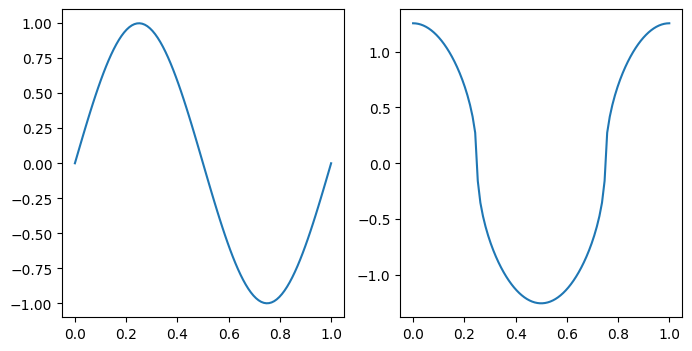

In [213]:
fig, axs = plt.subplots(1,2, figsize=(4*2, 4))
axs[0].plot(t.squeeze(), f.squeeze())
axs[1].plot(t.squeeze(), q.squeeze())
plt.show()

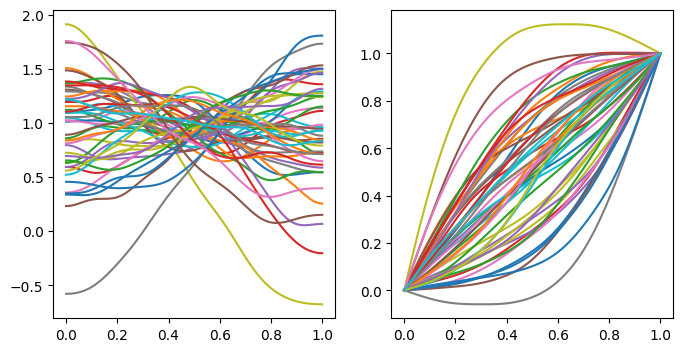

In [214]:
# Manifold operations
q = manifold.random(50)  # 5 random functions
f = manifold.srsf_to_function(q)
fig, axs = plt.subplots(1,2, figsize=(4*2, 4))
for i in range(50):
    axs[0].plot(t.squeeze(), q[i,...].squeeze())
    axs[1].plot(t.squeeze(), f[i,...].squeeze())
plt.show()

In [215]:
def batch_acqusition_mc(xy, q, model, manifold, T_max=T_MAX, T_min=T_MIN):
    fx = manifold.srsf_to_function(q)
    t_values = ((fx*(T_max - T_min)) + T_min)
    xy_expand = xy.view(-1, 1, 2).expand(t_values.shape[0], t_values.shape[1], -1)
    X = torch.cat([xy_expand, t_values], dim=-1).reshape(-1, 3)
    posterior = PosteriorModel(X, model)
    pred_samples = posterior.rsample(torch.Size((256,))).exp()
    probabilities = (pred_samples / pred_samples.sum(-2, keepdim=True)).mean(0)
    probabilities = probabilities.reshape(2, t_values.shape[0], t_values.shape[1])
    entropy = torch.special.entr(probabilities).sum(dim=0)

    return entropy

def batch_acqusition_xy(xy, model, manifold, n_samples = 32, **kwargs):
    q = manifold.random(n_samples)
    entropy = batch_acqusition_mc(xy, q, model, manifold, **kwargs)

    return entropy.mean(dim=0)

xy = draw_sobol_samples(bounds=bounds_xy, n=1, q=1).squeeze(0)
entropy = batch_acqusition_xy(xy, model, manifold, n_samples=32)
entropy.shape

torch.Size([100])

In [216]:
# Predict entropy of XY space (MC acquisition)
def acquisition(model, manifold, xy, q, T_max=T_MAX, T_min=T_MIN):
    fx = manifold.srsf_to_function(q).squeeze()
    t_values = ((fx*(T_max - T_min)) + T_min).squeeze(0)
    xy = xy.view(-1, 1, 2).expand(-1, len(t_values), -1).squeeze(0)
    X = torch.cat([xy, t_values.unsqueeze(-1)], dim=1).reshape(-1, 3)
    posterior = PosteriorModel(X, model)
    pred_samples = posterior.rsample(torch.Size((256,))).exp()
    probabilities = (pred_samples / pred_samples.sum(-2, keepdim=True)).mean(0)
    entropy = torch.special.entr(probabilities).sum(dim=0)

    return entropy

xy = draw_sobol_samples(bounds=bounds_xy, n=1, q=1).squeeze(0)
random_q = manifold.random(1)
entropy = acquisition(model, manifold, xy, random_q)
entropy

tensor([0.3222, 0.3413, 0.3614, 0.3826, 0.4048, 0.4280, 0.4522, 0.4772, 0.5028,
        0.5286, 0.5543, 0.5792, 0.6029, 0.6247, 0.6442, 0.6607, 0.6740, 0.6838,
        0.6901, 0.6929, 0.6926, 0.6894, 0.6838, 0.6761, 0.6670, 0.6567, 0.6456,
        0.6341, 0.6224, 0.6108, 0.5994, 0.5885, 0.5781, 0.5682, 0.5590, 0.5504,
        0.5424, 0.5351, 0.5282, 0.5219, 0.5161, 0.5107, 0.5059, 0.5014, 0.4974,
        0.4939, 0.4908, 0.4882, 0.4861, 0.4846, 0.4836, 0.4833, 0.4835, 0.4845,
        0.4862, 0.4886, 0.4919, 0.4962, 0.5016, 0.5082, 0.5161, 0.5256, 0.5368,
        0.5497, 0.5646, 0.5812, 0.5995, 0.6189, 0.6386, 0.6576, 0.6742, 0.6867,
        0.6928, 0.6907, 0.6786, 0.6557, 0.6221, 0.5787, 0.5272, 0.4701, 0.4101,
        0.3501, 0.2929, 0.2406, 0.1947, 0.1560, 0.1244, 0.0994, 0.0802, 0.0658,
        0.0551, 0.0475, 0.0422, 0.0388, 0.0370, 0.0366, 0.0376, 0.0400, 0.0438,
        0.0494], grad_fn=<SumBackward1>)

In [217]:
def acquisition_xy(xy, model, manifold, n_samples=16, **kwargs):
    random_q = manifold.random(n_samples)
    score = 0.0
    for q in random_q:
        entropy = acquisition(model, manifold, xy, q, **kwargs)
        score += entropy.mean() # take mean over different t values
    return score/n_samples # mean over n_samples

acquisition_xy(xy, model, manifold, n_samples=16)

tensor(0.3548, grad_fn=<DivBackward0>)

In [218]:
def optimize_xy(bounds, acqf, n_iterations=200, device="cpu"):
    X = draw_sobol_samples(bounds=bounds_xy, n=1, q=1).squeeze(0).to(device)
    X.requires_grad_(True)
    optimizer = torch.optim.Adam([X], lr=0.1)
    X_traj = []
    pbar = tqdm(range(n_iterations), desc="Optimizing XY")
    for _ in pbar:
        X_traj.append(X.clone().detach())
        optimizer.zero_grad()
        loss = -acqf(X)
        loss.backward() 
        optimizer.step()

        # clamp values to the feasible set
        for i, (lb, ub) in enumerate(zip(*bounds)):
            X.data[..., i].clamp_(lb, ub) 
            
        grad_mean = (X.grad.mean().item() if X.grad is not None else float('nan'))
        pbar.set_postfix(loss=loss.item(), grad_mean=grad_mean)
    
    return X.clone().detach(), torch.stack(X_traj, dim=1).squeeze()

In [220]:
# acqf = lambda X: acquisition_xy(X, model, manifold, n_samples=16)
acqf = lambda X: batch_acqusition_xy(X, model, manifold, n_samples=16).mean()
xy_star, trajectory = optimize_xy(bounds_xy, acqf)

Optimizing XY:   0%|          | 0/200 [00:00<?, ?it/s]/Users/knv2/Documents/codebase/envs/MaternGaBO/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
Optimizing XY: 100%|██████████| 200/200 [00:41<00:00,  4.82it/s, grad_mean=-0.00248, loss=-0.426] 


(<Figure size 640x480 with 2 Axes>, <Axes: >)

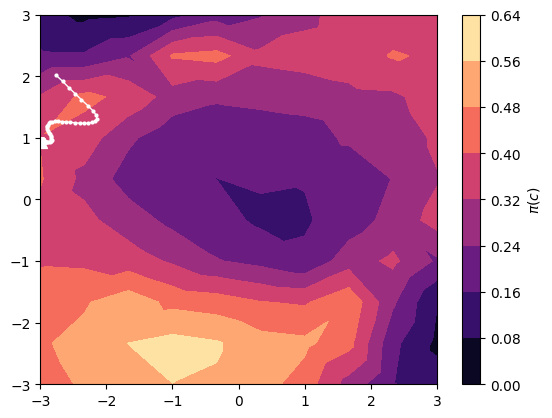

In [221]:
def plot_xy_optimization(acqf, grid_xy, xy_star, trajectory, ax=None):
    score_xy = np.asarray([acqf(xy).item() for xy in grid_xy])
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = plt.gcf()
    img = ax.tricontourf(
        grid_xy[:,0], 
        grid_xy[:,1], 
        score_xy, 
        cmap="magma"
    )
    ax.plot(
        trajectory[:,0], 
        trajectory[:,1], 
        "o-", 
        color="w", 
        lw=1.0, 
        markersize=2
    )
    ax.scatter(
        xy_star[:,0], 
        xy_star[:,1], 
        marker="^", 
        color="w", 
        s=50
    )
    fig.colorbar(img, ax=ax, label=r"$\pi(c)$")

    return fig, ax

plot_xy_optimization(acqf, grid_xy, xy_star, trajectory)

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]/Users/knv2/Documents/codebase/envs/MaternGaBO/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
Optimizing q: 100%|██████████| 50/50 [00:04<00:00, 11.87it/s, grad_mean=-0.000201, loss=-6.7] 


torch.Size([10, 100])


<Axes: xlabel='Time', ylabel='Temperature'>

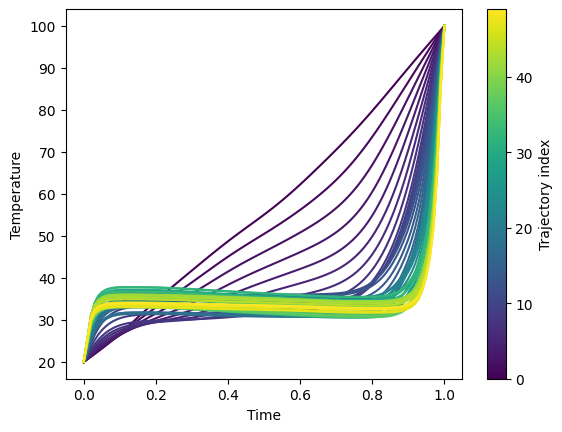

In [223]:
def optimize_f(model, manifold, xy_star, n_restarts = 10, n_iterations=50, **kwargs):
    q_init = manifold.random(n_restarts)
    q = geoopt.ManifoldParameter(q_init, manifold=manifold)
    opt = geoopt.optim.RiemannianAdam([q], lr=0.1)
    traj = []
    pbar = tqdm(range(n_iterations), desc="Optimizing q")
    loss_traj = []
    for _ in pbar:
        traj.append(q.clone().detach())
        opt.zero_grad()
        acqv = -batch_acqusition_mc(xy_star, q, model, manifold, **kwargs)
        loss_traj.append(acqv.clone().detach())
        loss = acqv.mean(dim=1).sum() # mean over different t-values
        loss.backward()
        opt.step()
        grad_mean = (q.grad.mean().item() if q.grad is not None else float('nan'))
        pbar.set_postfix(loss=loss.item(), grad_mean=grad_mean)
    print(acqv.shape)
    ind_star = acqv.mean(dim=1).argmin()    
    q_star = q[ind_star,...].clone().detach()
    fx_star = manifold.srsf_to_function(q_star.reshape(1,-1,1))
    f_star = Function(
        torch.linspace(0, 1, steps=manifold.sampling_points), 
        fx_star.reshape(-1, 1)
    )
    t_values = f_star(torch.linspace(0, 1, kwargs.get("n_steps", 5)))
    t_values = t_values*(kwargs.get("T_max", 100.0) - kwargs.get("T_min", 20.0)) \
        + kwargs.get("T_min", 20.0)

    return q_star, f_star, t_values, torch.stack(traj, dim=1).squeeze(), torch.stack(loss_traj, dim=1).squeeze(), ind_star

q_star, fx, t_values, trajectory, loss, ind = optimize_f(model, manifold, xy_star)
plot_function_optimization(trajectory[ind,...])

In [ ]:
def optimize_f(model, manifold, xy_star, n_iterations=50, **kwargs):
    q_init = manifold.random(1)
    q = geoopt.ManifoldParameter(q_init, manifold=manifold)
    opt = geoopt.optim.RiemannianAdam([q], lr=0.1)
    traj = []
    pbar = tqdm(range(n_iterations), desc="Optimizing q")
    loss_traj = []
    for _ in pbar:
        traj.append(q.clone().detach())
        opt.zero_grad()
        acqv = -acquisition(model, manifold, xy_star, q, **kwargs)
        loss_traj.append(acqv.clone().detach())
        loss = acqv.mean() # mean over different t-values
        loss.backward()
        opt.step()
        grad_mean = (q.grad.mean().item() if q.grad is not None else float('nan'))
        pbar.set_postfix(loss=loss.item(), grad_mean=grad_mean)
        
    q_star = q.clone().detach()
    fx_star = manifold.srsf_to_function(q_star.reshape(1,-1,1))
    f_star = Function(
        torch.linspace(0, 1, steps=manifold.sampling_points), 
        fx_star.reshape(-1, 1)
    )
    t_values = f_star(torch.linspace(0, 1, kwargs.get("n_steps", 5)))
    t_values = t_values*(kwargs.get("T_max", 100.0) - kwargs.get("T_min", 20.0)) \
        + kwargs.get("T_min", 20.0)

    return q_star, f_star, t_values, torch.stack(traj, dim=1).squeeze(), torch.stack(loss_traj, dim=1).squeeze()

In [ ]:
q_star, fx, t_values, trajectory, loss = optimize_f(model, manifold, xy_star)
t_values

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 63.82it/s, grad_mean=9.46e-5, loss=-0.683]  


tensor([[20.0000],
        [25.5457],
        [25.5348],
        [25.4296],
        [99.9999]])

ValueError: x and y must have same first dimension, but have shapes (100,) and (5000,)

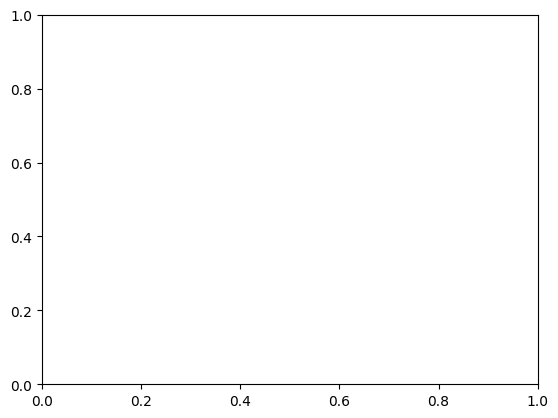

In [ ]:
def plot_function_optimization(trajectory, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = plt.gcf()
    cmap = plt.get_cmap("viridis")
    norm = MPLNormalize(vmin=0, vmax=trajectory.shape[0] - 1)
    for i in range(trajectory.shape[0]):
        fx = manifold.srsf_to_function(trajectory[i,...].reshape(1, -1, 1))
        ax.plot(
            np.linspace(0, 1, manifold.sampling_points),
            T_MIN + (T_MAX-T_MIN)*fx.squeeze(),
            color=cmap(norm(i)),
        )
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature")
    sm = ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=ax, label="Trajectory index")

    return ax

plot_function_optimization(trajectory)

In [ ]:
def plot_active_learning_data(train_X, train_Y, xy_star, t_values, ax = None):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1, projection="3d")
    else:
        fig = plt.gcf()
    colors = np.where(train_Y > 0.5, "#ef4444", "#2563eb").squeeze()
    ax.scatter(
        train_X[:, 0], train_X[:, 1], train_X[:, 2],
        c=colors,
        **scatter_kwargs
    )
    for t in t_values:
        ax.scatter(
            xy_star[:, 0], xy_star[:, 1], t,
            color="k",
            s=50,
            depthshade=False,
            edgecolors="k",
            linewidths=0.6,
        )
    return fig, ax

In [ ]:
def make_gridspec():
    fig = plt.figure(layout="constrained", figsize=(4*2, 4*2))

    # Outer structure: 2 rows (top, bottom), 1 column
    outer = GridSpec(2, 1, figure=fig, height_ratios=[1,1])

    # Top row: 1×3
    gs_top = GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[0])
    ax1 = fig.add_subplot(gs_top[0, 0], projection="3d")
    ax2 = fig.add_subplot(gs_top[0, 1], projection="3d")
    ax3 = fig.add_subplot(gs_top[0, 2], projection="3d")
    for ax in [ax1, ax2, ax3]:
        ax.set_xlim(bounds[:,0].numpy())
        ax.set_ylim(bounds[:,1].numpy())
        ax.set_zlim(bounds[:,2].numpy())

    # Bottom row: 1×2 spanning full width
    gs_bottom = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1])
    ax4 = fig.add_subplot(gs_bottom[0, 0])
    ax4.set_xlim(bounds[:,0].numpy())
    ax4.set_ylim(bounds[:,1].numpy())
    ax5 = fig.add_subplot(gs_bottom[0, 1])

    return fig, [[ax1, ax2, ax3], [ax4, ax5]]

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 71.86it/s, grad_mean=-1.01e-5, loss=-0.689]


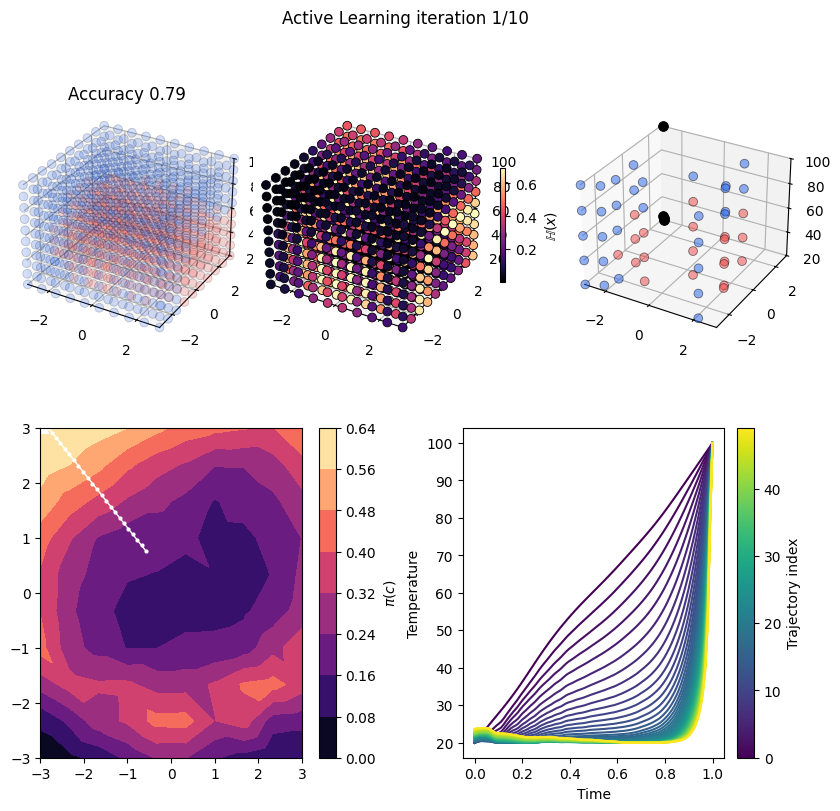

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 73.48it/s, grad_mean=3.61e-5, loss=-0.675]  


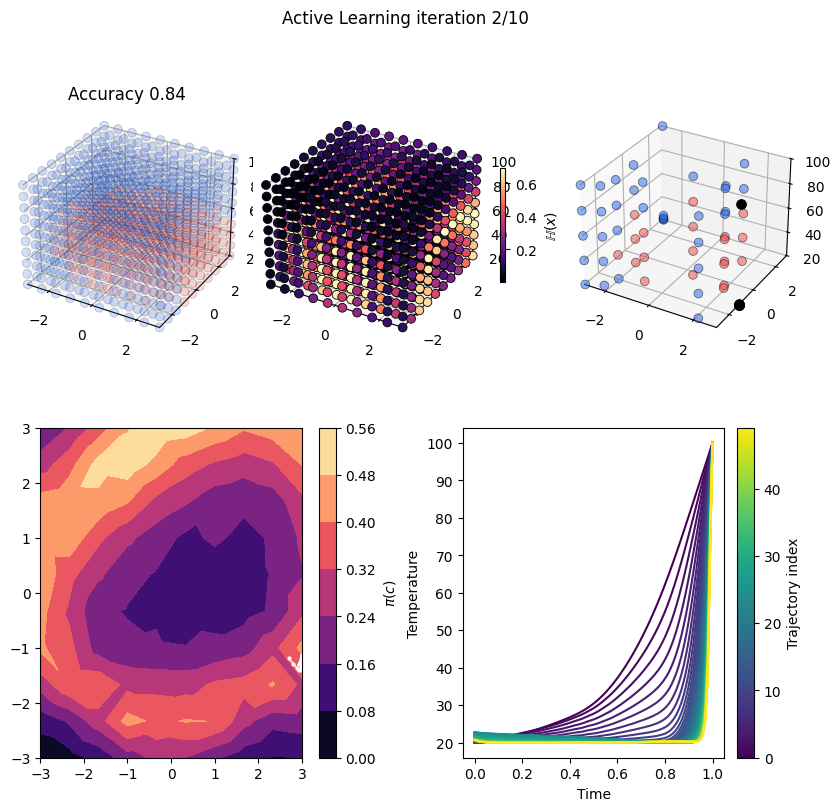

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 72.98it/s, grad_mean=0.000123, loss=-0.685] 


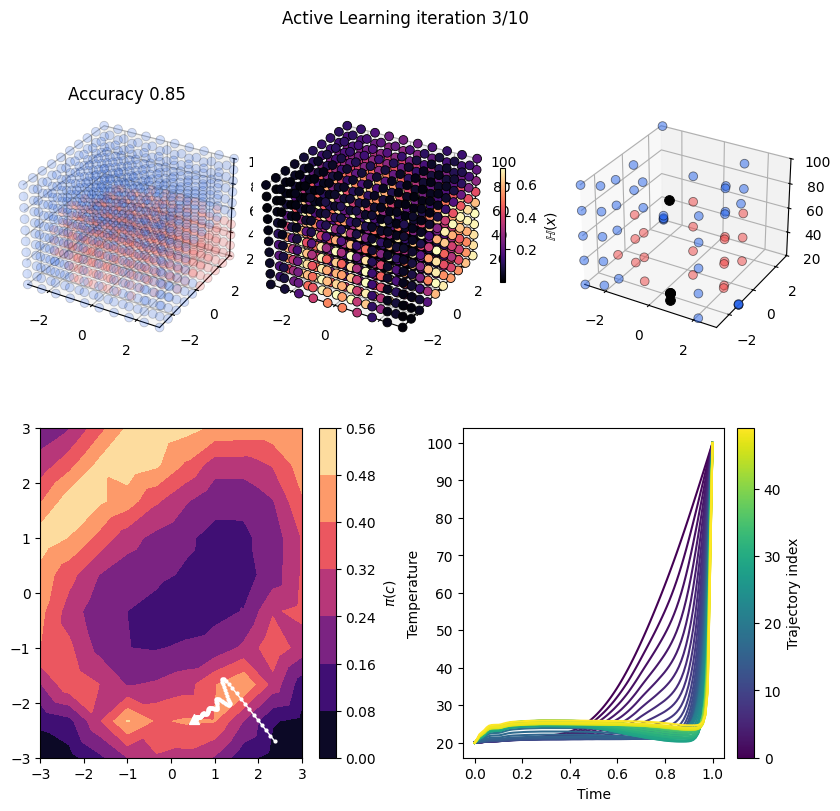

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 61.41it/s, grad_mean=0.000107, loss=-0.679] 


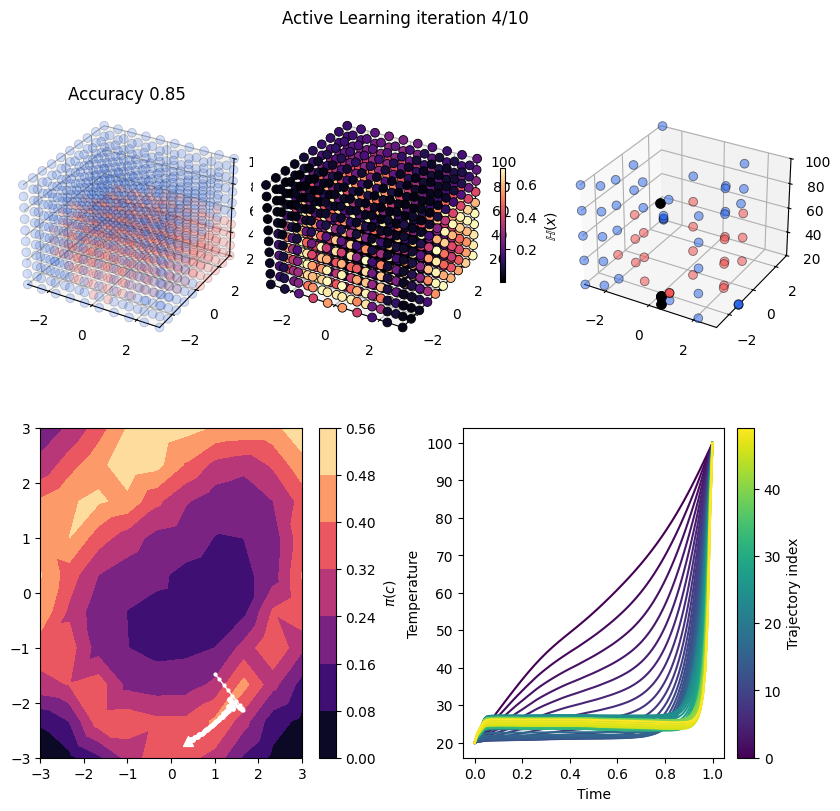

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 68.31it/s, grad_mean=9.63e-5, loss=-0.684]  


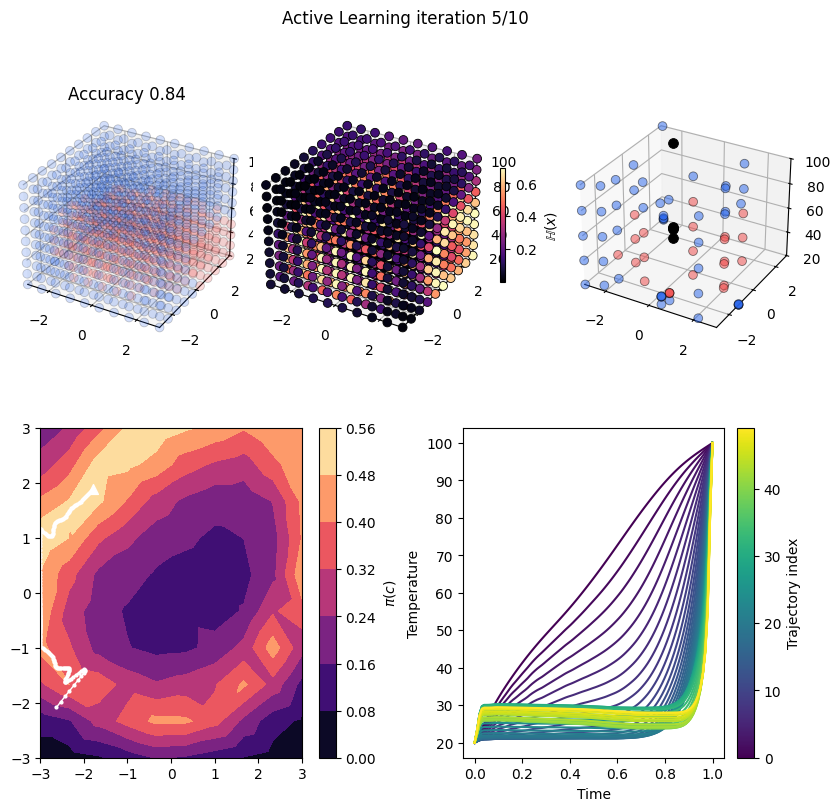

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 69.17it/s, grad_mean=-0.000158, loss=-0.674]


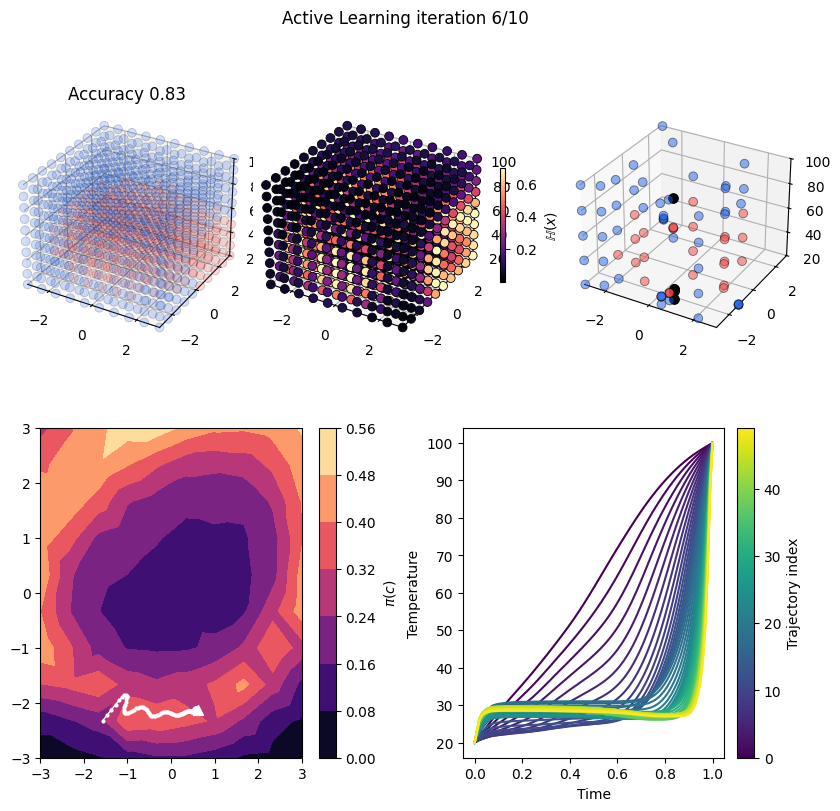

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 69.57it/s, grad_mean=9.79e-5, loss=-0.682]  


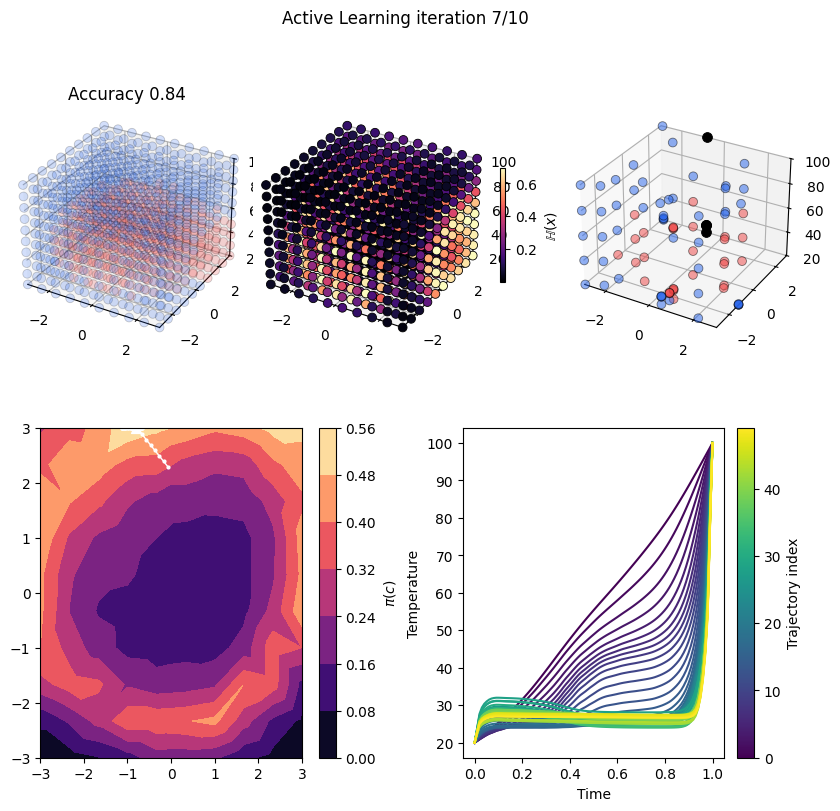

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 67.81it/s, grad_mean=0.000248, loss=-0.677] 


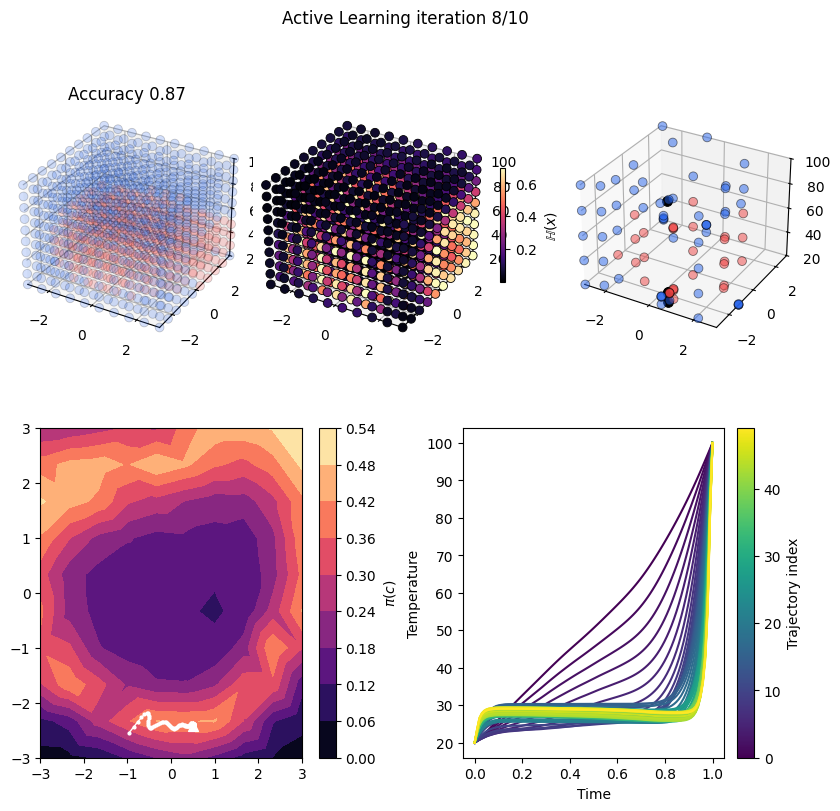

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 69.60it/s, grad_mean=0.00037, loss=-0.675]  


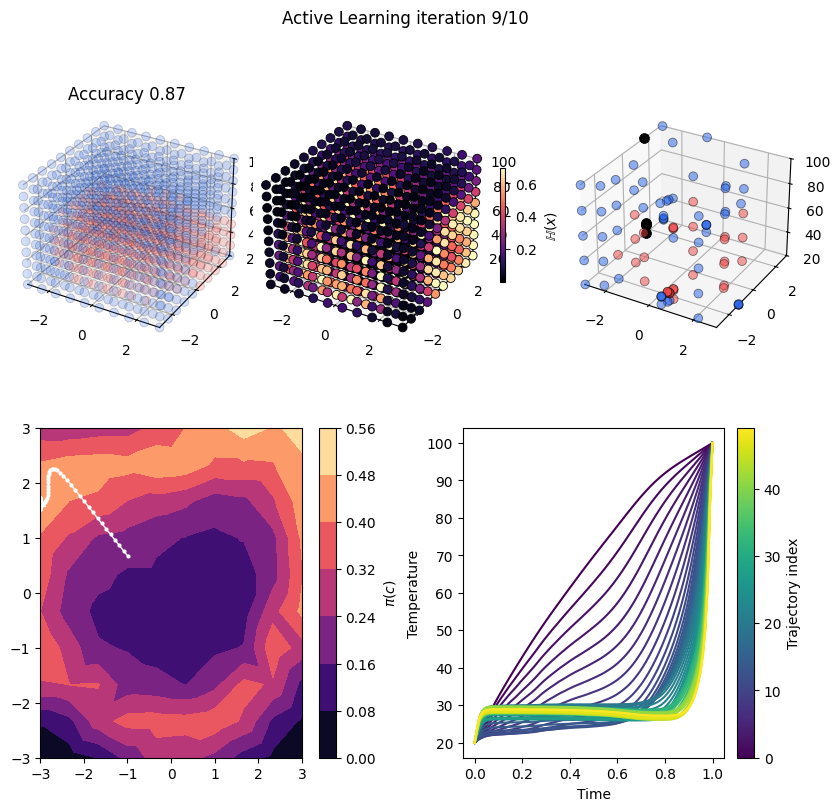

Optimizing q: 100%|██████████| 50/50 [00:00<00:00, 67.59it/s, grad_mean=2.95e-5, loss=-0.678]  


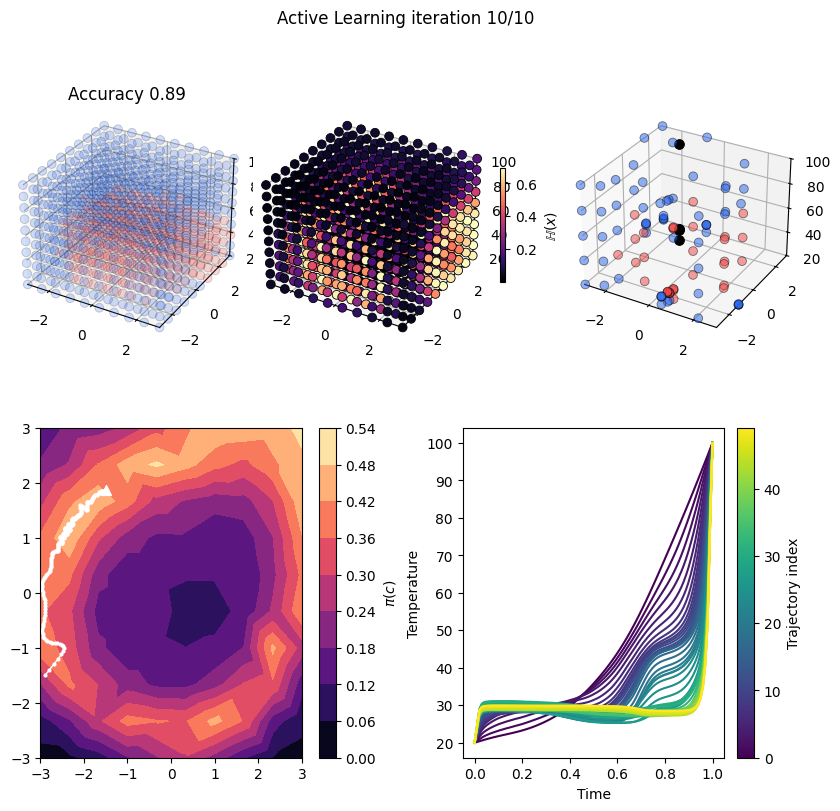

In [ ]:
n_iterations = 10
for i in range(n_iterations):
    fig, axs = make_gridspec()
    likelihood = DirichletClassificationLikelihood(
        train_Y.long().squeeze(), 
        learn_additional_noise=True
    )
    model = DirichletGPModel(
        train_X, 
        likelihood.transformed_targets, 
        likelihood, 
        num_classes = likelihood.num_classes,
        transform = Normalize(d=3, bounds = bounds)
        )
    model, likelihood = fit_dirchlet_gp(train_X, model, likelihood, n_iterations=50)
    plot_model_posterior(model, grid_xyz, ax=[axs[0][0], axs[0][1]])
    
    # optimize composition space in R^2
    acqf = lambda X: acquisition_xy(X, model, manifold, n_samples=16)
    xy_star, trajectory_xy = optimize_xy(bounds_xy, acqf)
    plot_xy_optimization(acqf, grid_xy, xy_star, trajectory_xy, ax=axs[1][0])
    
    # optimize temperature profile in S_{\inf}
    q_star, f_star, t_values, trajectory_f, loss_traj_f = optimize_f(model, manifold, xy_star)
    plot_function_optimization(trajectory_f, ax=axs[1][1])
    
    plot_active_learning_data(train_X, train_Y, xy_star, t_values, ax=axs[0][2])

    # update dataset
    new_Y = ball.label(xy_star.squeeze(), t_values)
    xy_star_expanded = xy_star.view(-1, 1, 2).expand(-1, len(t_values), -1).squeeze(0)
    new_X = torch.cat([xy_star_expanded.squeeze(), t_values], dim=1)
    
    train_X = torch.cat((train_X, new_X))
    train_Y = torch.cat((train_Y, new_Y.reshape(-1, 1)))
    fig.suptitle(f"Active Learning iteration {i+1}/{n_iterations}")
    plt.show()